## 1. Giới thiệu

Bộ dữ liệu này có tên là `shopping_trends.csv` (hoặc `shopping_trends_updated.csv`) chứa thông tin chi tiết về các xu hướng mua sắm của khách hàng. Nó bao gồm 3900 bản ghi với 19 thuộc tính (hoặc 18 thuộc tính, tùy thuộc vào tập dữ liệu cụ thể đang được xem xét), cung cấp cái nhìn sâu sắc về hành vi mua hàng của người tiêu dùng.

Các cột chính bao gồm:
-   **Customer ID**: Mã định danh duy nhất cho mỗi khách hàng.
-   **Age**: Tuổi của khách hàng.
-   **Gender**: Giới tính của khách hàng.
-   **Item Purchased**: Sản phẩm mà khách hàng đã mua.
-   **Category**: Danh mục của sản phẩm đã mua (ví dụ: Clothing, Footwear, Accessories).
-   **Purchase Amount (USD)**: Số tiền mua hàng bằng Đô la Mỹ.
-   **Location**: Vị trí địa lý của khách hàng.
-   **Size**: Kích thước của sản phẩm đã mua.
-   **Color**: Màu sắc của sản phẩm đã mua.
-   **Season**: Mùa mà giao dịch mua hàng được thực hiện.
-   **Review Rating**: Đánh giá sản phẩm.
-   **Subscription Status**: Trạng thái đăng ký của khách hàng (có hoặc không).
-   **Shipping Type**: Loại hình vận chuyển được sử dụng.
-   **Discount Applied**: Cho biết có áp dụng chiết khấu hay không.
-   **Promo Code Used**: Cho biết có sử dụng mã khuyến mãi hay không.
-   **Previous Purchases**: Số lượng các lần mua hàng trước đó của khách hàng.
-   **Payment Method**: Phương thức thanh toán được sử dụng.
-   **Frequency of Purchases**: Tần suất mua hàng của khách hàng
(ví dụ: Weekly, Fortnightly, Annually).

Bộ dữ liệu này có thể được sử dụng để phân tích các yếu tố ảnh hưởng đến quyết định mua hàng,
xu hướng theo mùa, hành vi của khách hàng theo nhân khẩu học,
và hiệu quả của các chiến dịch giảm giá/khuyến mãi.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
!pip install fastFM
from fastFM import als

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 19.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for fastFM: filename=fastFM-0.2.10-cp312-cp312-linux_x86_64.whl size=660957 sha256=a5055338f695763e84915cac9d8160b5954c424f4962b44a96a2cae04f62fcb8
  Stored in directory: /root/.cache/pip/wheels/05/3e/62/4910464465a0df01d7eb87bf5101d306ee89b2d690633b70f4
Successfully built fastFM


In [ ]:
df = pd.read_csv('/content/shopping_trends.csv')
df

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,3896,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,Cash,2-Day Shipping,No,No,32,Venmo,Weekly
3896,3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,PayPal,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
3897,3898,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Credit Card,Standard,No,No,24,Venmo,Quarterly
3898,3899,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,PayPal,Express,No,No,24,Venmo,Weekly


In [ ]:
df.shape

(3900, 19)

##2. Xử lý các giá trị thiếu

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               3900 non-null   int64  
 1   Age                       3900 non-null   int64  
 2   Gender                    3900 non-null   object 
 3   Item Purchased            3900 non-null   object 
 4   Category                  3900 non-null   object 
 5   Purchase Amount (USD)     3900 non-null   int64  
 6   Location                  3900 non-null   object 
 7   Size                      3900 non-null   object 
 8   Color                     3900 non-null   object 
 9   Season                    3900 non-null   object 
 10  Review Rating             3900 non-null   float64
 11  Subscription Status       3900 non-null   object 
 12  Payment Method            3900 non-null   object 
 13  Shipping Type             3900 non-null   object 
 14  Discount

##3. Thống kê mô tả

Trước khi tiền xử lý, nhóm sử dụng thống kê mô tả để quan sát nhanh phân bố của các biến số trong tập train.  
Các chỉ số như giá trị trung bình, độ lệch chuẩn, min, max và các phân vị giúp nhóm hiểu được quy mô và mức độ biến động của dữ liệu

In [ ]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.749949,25.351538
std,1125.977353,15.207589,23.685392,0.716223,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.700000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


###4. Kiểm tra outlier

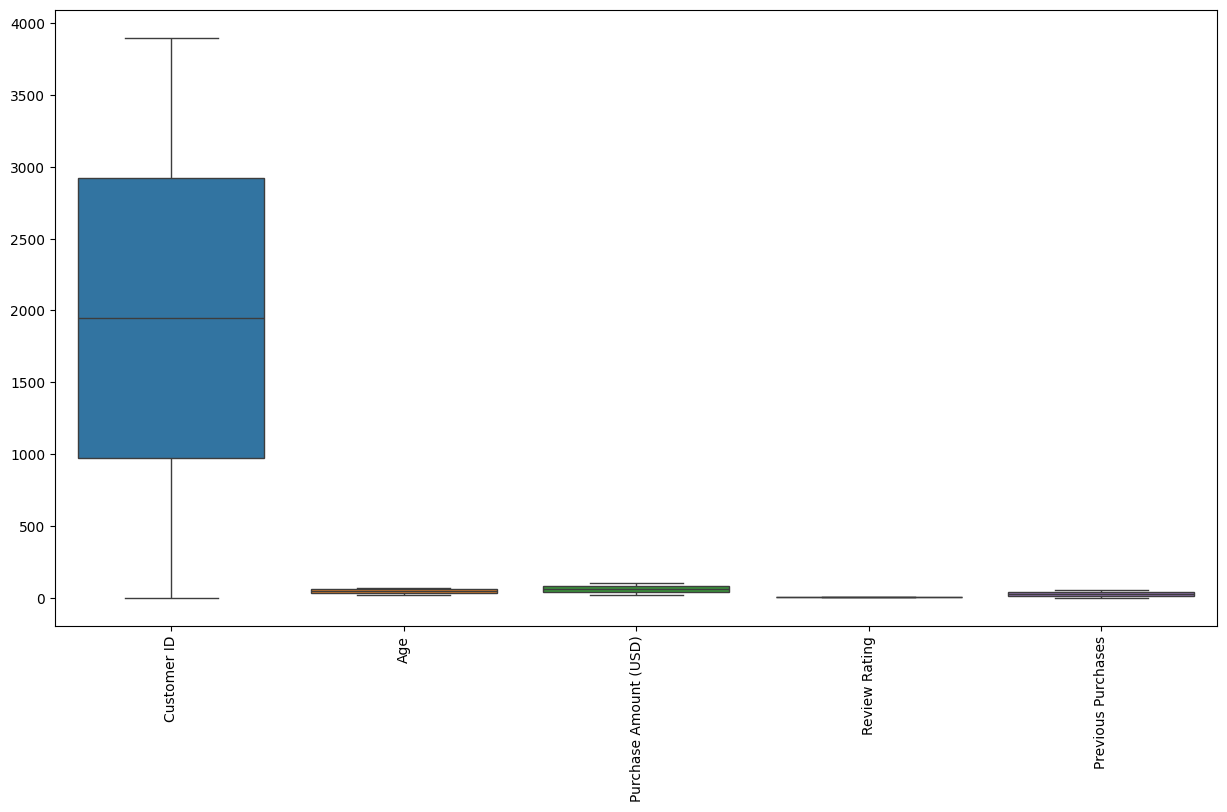

In [ ]:
plt.figure(figsize=(15,8))
sns.boxplot(df)
plt.xticks(rotation=90)
plt.show()

In [ ]:
y =df['Purchase Amount (USD)']
X = df.drop(columns=['Purchase Amount (USD)', 'Customer ID'])


In [ ]:
taget

,Purchase Amount (USD)
0,53
1,64
2,73
3,90
4,49
...,...
3895,28
3896,49
3897,33
3898,77


##5. One-Hot Encoding

In [ ]:
from sklearn.preprocessing import OneHotEncoder
encoder=OneHotEncoder()

In [ ]:
Custome =df[["Gender","Category","Location","Season","Subscription Status",
               "Payment Method","Shipping Type","Frequency of Purchases"]]
Custome_hot=encoder.fit_transform(Custome)
Custome_hot

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 31200 stored elements and shape (3900, 81)>

In [ ]:
from scipy.sparse import csc_matrix
Shopping = pd.DataFrame.sparse.from_spmatrix(csc_matrix(Custome_hot),
                                                 columns=encoder.get_feature_names_out(),index=df.index)
Shopping

,Gender_Female,Gender_Male,Category_Accessories,Category_Clothing,Category_Footwear,Category_Outerwear,Location_Alabama,Location_Alaska,Location_Arizona,Location_Arkansas,...,Shipping Type_Next Day Air,Shipping Type_Standard,Shipping Type_Store Pickup,Frequency of Purchases_Annually,Frequency of Purchases_Bi-Weekly,Frequency of Purchases_Every 3 Months,Frequency of Purchases_Fortnightly,Frequency of Purchases_Monthly,Frequency of Purchases_Quarterly,Frequency of Purchases_Weekly
0,0,1.0,0,1.0,0,0,0,0,0,0,...,0,0,0,0,0,0,1.0,0,0,0
1,0,1.0,0,1.0,0,0,0,0,0,0,...,0,0,0,0,0,0,1.0,0,0,0
2,0,1.0,0,1.0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1.0
3,0,1.0,0,0,1.0,0,0,0,0,0,...,1.0,0,0,0,0,0,0,0,0,1.0
4,0,1.0,0,1.0,0,0,0,0,0,0,...,0,0,0,1.0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,1.0,0,0,1.0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1.0
3896,1.0,0,1.0,0,0,0,0,0,0,0,...,0,0,1.0,0,1.0,0,0,0,0,0
3897,1.0,0,1.0,0,0,0,0,0,0,0,...,0,1.0,0,0,0,0,0,0,1.0,0
3898,1.0,0,0,0,1.0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1.0


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
X_train_encoded = pd.get_dummies(X_train, columns=categorical_features, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_features, drop_first=True)

##6. Chuẩn hóa dữ liệu

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [ ]:
categorical_features = X_train.select_dtypes(include=['object']).columns

X_train_encoded = pd.get_dummies(X_train, columns=categorical_features, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_features, drop_first=True)

all_columns = X_train_encoded.columns.union(X_test_encoded.columns)

X_train_aligned = X_train_encoded.reindex(columns=all_columns, fill_value=0)
X_test_aligned = X_test_encoded.reindex(columns=all_columns, fill_value=0)

X_test_aligned = X_test_aligned[X_train_aligned.columns]

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_aligned)
X_test = scaler.transform(X_test_aligned)

In [ ]:
from scipy.sparse import csc_matrix
X_train_sparse = csc_matrix(X_train)
X_test_sparse = csc_matrix(X_test)
X_train_sparse
X_test_sparse

<Compressed Sparse Column sparse matrix of dtype 'float64'
	with 104520 stored elements and shape (780, 134)>

##7. Đánh giá mô hình

In [ ]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()

In [ ]:
lin_reg.fit(X_train, y_train)

LinearRegression()

In [ ]:
k=lin_reg.predict(X_test)

In [ ]:
from sklearn.metrics import r2_score
r2_score(y_test, k )

-0.030912715359136422

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
mean_squared_error(y_test, k)

576.8805823741571